In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


#**KNN**


In [2]:
import os
import cv2
import joblib
import time
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn import metrics
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report



In [3]:

# Load the previously saved HOG features and labels
all_features = np.load('/content/drive/MyDrive/drowsiness_added_methods/hog_features_YawDD.npy')
all_labels = np.load('/content/drive/MyDrive/drowsiness_added_methods/labels_YawDD.npy')
# Shuffle the dataset
random_indices = np.random.permutation(len(all_features))
shuffled_features = all_features[random_indices]
shuffled_labels = all_labels[random_indices]

# Split the dataset into training and testing subsets
train_features, test_features, train_labels, test_labels = train_test_split(
    shuffled_features, shuffled_labels, test_size=0.2, random_state=42
)

print("Number of training samples:", len(train_features))
print("Number of testing samples:", len(test_features))



Number of training samples: 13189
Number of testing samples: 3298


In [4]:
# Define a range of n_neighbors values to test
n_neighbors_values = range(1, 21)  # Adjust the range as needed

best_accuracy = 0
best_n_neighbors = 0

# Iterate over different n_neighbors values
for n_neighbors in n_neighbors_values:
    # Create a K-Nearest Neighbors classifier
    knn_classifier = KNeighborsClassifier(n_neighbors=n_neighbors)

    # Train the KNN classifier
    knn_classifier.fit(train_features, train_labels)

    # Predict labels for the test set
    test_predicted_labels = knn_classifier.predict(test_features)
    test_accuracy = metrics.accuracy_score(test_labels, test_predicted_labels)

    # Update the best parameters if the current model is better
    if test_accuracy > best_accuracy:
        best_accuracy = test_accuracy
        best_n_neighbors = n_neighbors

# Print the best parameters
print("Best n_neighbors:", best_n_neighbors)
print("Best Test Accuracy:", best_accuracy)

Best n_neighbors: 1
Best Test Accuracy: 0.9651303820497271


In [5]:


# Create the final K-Nearest Neighbors classifier with the best n_neighbors

knn_classifier = KNeighborsClassifier(n_neighbors=best_n_neighbors)

t3=time.time()
# Train the final KNN classifier
knn_classifier.fit(train_features, train_labels)
# Predict labels for the training set
train_predicted_labels = knn_classifier.predict(train_features)
t4= time.time()
temps_execution = t4 - t3
print(f"Le temps de train de KNN est de {temps_execution} secondes.")
train_accuracy = metrics.accuracy_score(train_labels, train_predicted_labels)


t5=time.time()
# Predict labels for the test set
test_predicted_labels3 = knn_classifier.predict(test_features)
test_accuracy = metrics.accuracy_score(test_labels, test_predicted_labels3)
t6= time.time()
temps_execution = t6 - t5
print(f"Le temps de test de KNN {temps_execution} secondes.")
# Print accuracies
print("Training Accuracy:", train_accuracy)
print("Testing Accuracy:", test_accuracy)

# Save the trained KNN model to a file
model_filename = 'knn_model.pkl'
joblib.dump(knn_classifier, model_filename)
print("Model saved!")

Le temps de train de KNN est de 24.077122926712036 secondes.
Le temps de test de KNN 6.955280303955078 secondes.
Training Accuracy: 1.0
Testing Accuracy: 0.9651303820497271
Model saved!


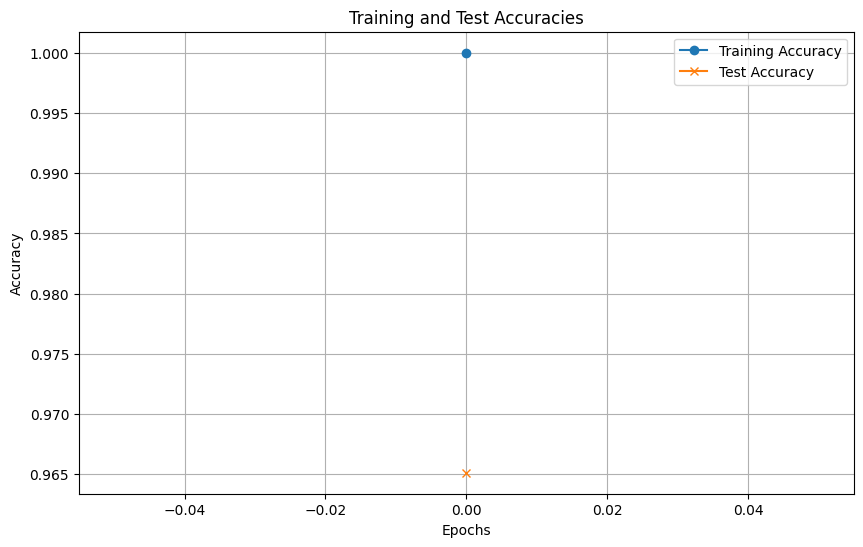

In [6]:
# Plot Training and Test Accuracies
plt.figure(figsize=(10, 6))
plt.plot(train_accuracy, label='Training Accuracy', marker='o')
plt.plot(test_accuracy, label='Test Accuracy', marker='x')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Test Accuracies')
plt.legend()
plt.grid(True)
plt.show()

In [7]:
from sklearn import metrics
import numpy as np
from sklearn.metrics import f1_score
# Model Precision: what percentage of positive tuples are labeled as such?
print("Precision:",metrics.precision_score(test_labels, test_predicted_labels3))

# Model Recall: what percentage of positive tuples are labelled as such?
print("Recall:",metrics.recall_score(test_labels, test_predicted_labels3))
#F1_score
print('f1_score=',f1_score(test_labels, test_predicted_labels3, average='macro'))

Precision: 0.962010520163647
Recall: 0.9705188679245284
f1_score= 0.9650922514591221


In [8]:
import numpy as np
from sklearn.metrics import det_curve
fpr, fnr, thresholds = det_curve(test_labels, test_predicted_labels3)
print(fpr)
print(fnr)

[1.         0.04057428]
[0.         0.02948113]


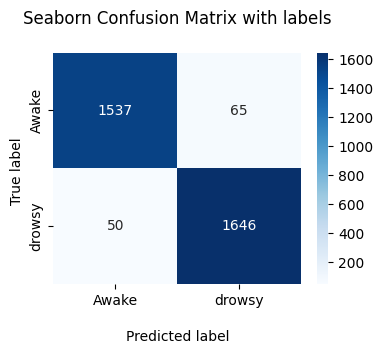

In [9]:
from sklearn.metrics import confusion_matrix
# importing library for plotting
import matplotlib.pyplot as plt
# plot the confusion matrix
f,ax = plt.subplots(figsize=(4,3))
#Generate the confusion matrix
cf_matrix = confusion_matrix(test_labels, test_predicted_labels3)
import seaborn as sns

ax = sns.heatmap(cf_matrix, annot=True, cmap=plt.cm.Blues, fmt='g')

ax.set_title('Seaborn Confusion Matrix with labels\n');
ax.set_xlabel('\nPredicted label')
ax.set_ylabel('True label ');

## Ticket labels - List must be in alphabetical order
ax.xaxis.set_ticklabels(['Awake','drowsy'])
ax.yaxis.set_ticklabels(['Awake','drowsy'])

## Display the visualization of the Confusion Matrix.
plt.show()

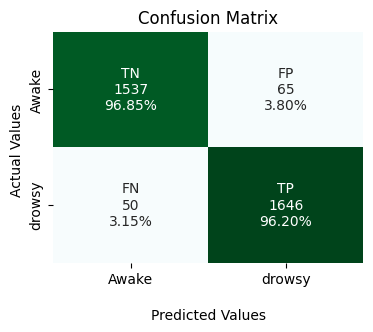

In [10]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Assuming you have y_test and predictions1 defined

# Generate the confusion matrix
cf_matrix = confusion_matrix(test_labels, test_predicted_labels3)

# Calculate column-wise percentages
cf_col_percentages = cf_matrix / np.sum(cf_matrix, axis=0) * 100

# Group names, counts, and percentages
group_counts = ["{0:0.0f}".format(value) for value in cf_matrix.flatten()]
group_names = ['TN', 'FP', 'FN', 'TP']
group_col_percentages = ["{0:.2f}%".format(value) for value in cf_col_percentages.flatten()]
labels = [f"{v1}\n{v2}\n{v3}" for v1, v2, v3 in zip(group_names,group_counts, group_col_percentages)]
labels = np.asarray(labels).reshape(2, 2)


# Plot the confusion matrix with annotations and use a clear green color
f, ax = plt.subplots(figsize=(4, 3))
sns.heatmap(cf_matrix, annot=labels, fmt='', cmap='BuGn', cbar=False)

# Set labels
ax.set_title('Confusion Matrix')
ax.set_xlabel('\nPredicted Values')



ax.set_ylabel('Actual Values ')

# Set tick labels
ax.xaxis.set_ticklabels(['Awake','drowsy'])
ax.yaxis.set_ticklabels(['Awake','drowsy'])

# Display the visualization of the Confusion Matrix
plt.show()


AUC for our classifier is: 0.9649722928886063


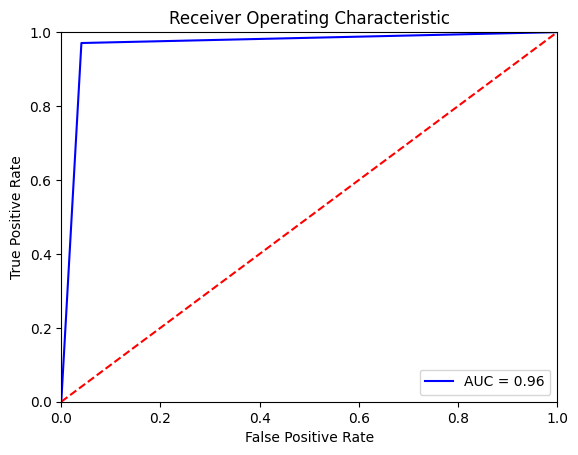

In [11]:
# Importing all necessary libraries
from sklearn.metrics import roc_curve, auc

fpr, tpr, threshold = roc_curve(test_labels, test_predicted_labels3)
roc_auc = auc(fpr, tpr)

# Printing AUC
print(f"AUC for our classifier is: {roc_auc}")

# Plotting the ROC
plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr, 'b', label = 'AUC = %0.2f' % roc_auc)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

# **SVM**

In [12]:
import os
import time
import cv2
import numpy as np
from sklearn import svm, metrics
from sklearn.model_selection import train_test_split

In [13]:

# Create an SVM classifier (you can adjust the kernel and other parameters)
classifier = svm.SVC(kernel='linear')
t7=time.time()
# Train the classifier
classifier.fit(train_features, train_labels)
t8= time.time()
temps_execution = t8 - t7
print(f"Le temps d'etrai de SVM {temps_execution} secondes.")
# Predict labels for the training set


train_predicted_labels = classifier.predict(train_features)
train_accuracy = metrics.accuracy_score(train_labels, train_predicted_labels)
t9=time.time()
# Predict labels for the test set
test_predicted_labels4 = classifier.predict(test_features)
test_accuracy = metrics.accuracy_score(test_labels, test_predicted_labels4)
t10= time.time()
temps_execution = t10 - t9
print(f"Le temps d'test  de SVM est de {temps_execution} secondes.")
# Print accuracies
print("Training Accuracy:", train_accuracy)
print("Testing Accuracy:", test_accuracy)

import joblib

# Save the trained SVM model to a file
model_filename = 'svm_model.pkl'
joblib.dump(classifier, model_filename)
print("Model saved!")


Le temps d'etrai de SVM 1089.3866245746613 secondes.
Le temps d'test  de SVM est de 250.13222575187683 secondes.
Training Accuracy: 1.0
Testing Accuracy: 0.9408732565191025
Model saved!


In [14]:
from sklearn import metrics
import numpy as np
from sklearn.metrics import f1_score
# Model Precision: what percentage of positive tuples are labeled as such?
print("Precision:",metrics.precision_score(test_labels, test_predicted_labels4))

# Model Recall: what percentage of positive tuples are labelled as such?
print("Recall:",metrics.recall_score(test_labels, test_predicted_labels4))
#F1_score
print('f1_score=',f1_score(test_labels, test_predicted_labels4, average='macro'))

Precision: 0.9427728613569322
Recall: 0.9422169811320755
f1_score= 0.9408262027915502


In [15]:
import numpy as np
from sklearn.metrics import det_curve
fpr, fnr, thresholds = det_curve(test_labels, test_predicted_labels4)
print(fpr)
print(fnr)

[1.         0.06054931]
[0.         0.05778302]


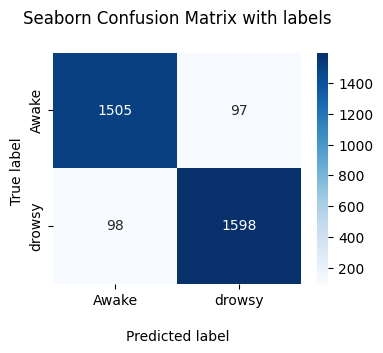

In [16]:
from sklearn.metrics import confusion_matrix
# importing library for plotting
import matplotlib.pyplot as plt
# plot the confusion matrix
f,ax = plt.subplots(figsize=(4,3))
#Generate the confusion matrix
cf_matrix = confusion_matrix(test_labels, test_predicted_labels4)
import seaborn as sns

ax = sns.heatmap(cf_matrix, annot=True, cmap=plt.cm.Blues, fmt='g')

ax.set_title('Seaborn Confusion Matrix with labels\n');
ax.set_xlabel('\nPredicted label')
ax.set_ylabel('True label ');

## Ticket labels - List must be in alphabetical order
ax.xaxis.set_ticklabels(['Awake','drowsy'])
ax.yaxis.set_ticklabels(['Awake','drowsy'])

## Display the visualization of the Confusion Matrix.
plt.show()

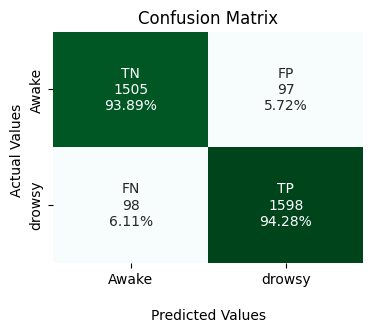

In [17]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Assuming you have y_test and predictions1 defined

# Generate the confusion matrix
cf_matrix = confusion_matrix(test_labels, test_predicted_labels4)

# Calculate column-wise percentages
cf_col_percentages = cf_matrix / np.sum(cf_matrix, axis=0) * 100

# Group names, counts, and percentages
group_counts = ["{0:0.0f}".format(value) for value in cf_matrix.flatten()]
group_names = ['TN', 'FP', 'FN', 'TP']
group_col_percentages = ["{0:.2f}%".format(value) for value in cf_col_percentages.flatten()]
labels = [f"{v1}\n{v2}\n{v3}" for v1, v2, v3 in zip(group_names,group_counts, group_col_percentages)]
labels = np.asarray(labels).reshape(2, 2)


# Plot the confusion matrix with annotations and use a clear green color
f, ax = plt.subplots(figsize=(4, 3))
sns.heatmap(cf_matrix, annot=labels, fmt='', cmap='BuGn', cbar=False)

# Set labels
ax.set_title('Confusion Matrix')
ax.set_xlabel('\nPredicted Values')
ax.set_ylabel('Actual Values ')

# Set tick labels
ax.xaxis.set_ticklabels(['Awake','drowsy'])
ax.yaxis.set_ticklabels(['Awake','drowsy'])

# Display the visualization of the Confusion Matrix
plt.show()

AUC for our classifier is: 0.9408338338868867


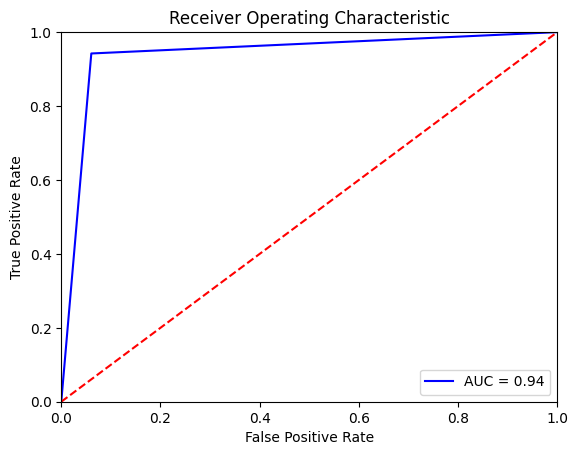

In [18]:
# Importing all necessary libraries
from sklearn.metrics import roc_curve, auc

fpr, tpr, threshold = roc_curve(test_labels, test_predicted_labels4)
roc_auc = auc(fpr, tpr)

# Printing AUC
print(f"AUC for our classifier is: {roc_auc}")

# Plotting the ROC
plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr, 'b', label = 'AUC = %0.2f' % roc_auc)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

# **DT**

In [19]:
# Create a Decision Tree classifier (you can adjust the parameters)
classifier = DecisionTreeClassifier(random_state=42)
t7 = time.time()
# Train the classifier
classifier.fit(train_features, train_labels)
t8 = time.time()
temps_execution = t8 - t7
print(f"Le temps d'entrainement du Decision Tree est de {temps_execution} secondes.")

# Predict labels for the training set
train_predicted_labels = classifier.predict(train_features)
train_accuracy = metrics.accuracy_score(train_labels, train_predicted_labels)

t9 = time.time()


Le temps d'entrainement du Decision Tree est de 1585.978840827942 secondes.


In [20]:
# Predict labels for the test set
test_predicted_labels1 = classifier.predict(test_features)
t10 = time.time()
temps_execution = t10 - t9
test_accuracy = metrics.accuracy_score(test_labels, test_predicted_labels1)
print(f"Le temps de test du Decision Tree est de {temps_execution} secondes.")

# Print accuracies
print("Training Accuracy:", train_accuracy)
print("Testing Accuracy:", test_accuracy)

Le temps de test du Decision Tree est de 0.3944528102874756 secondes.
Training Accuracy: 1.0
Testing Accuracy: 0.7877501516070345


In [21]:
# Save the trained Decision Tree model to a file
model_filename = 'decision_tree_model.pkl'
joblib.dump(classifier, model_filename)
print("Model saved!")

Model saved!


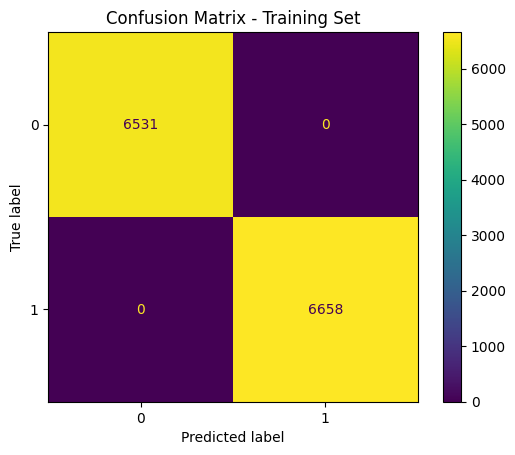

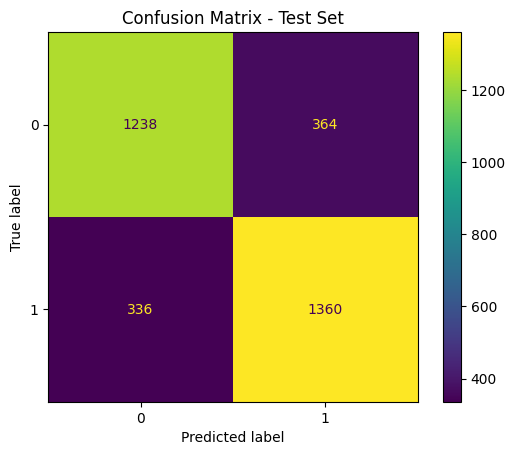

Classification Report - Test Set
              precision    recall  f1-score   support

           0       0.79      0.77      0.78      1602
           1       0.79      0.80      0.80      1696

    accuracy                           0.79      3298
   macro avg       0.79      0.79      0.79      3298
weighted avg       0.79      0.79      0.79      3298



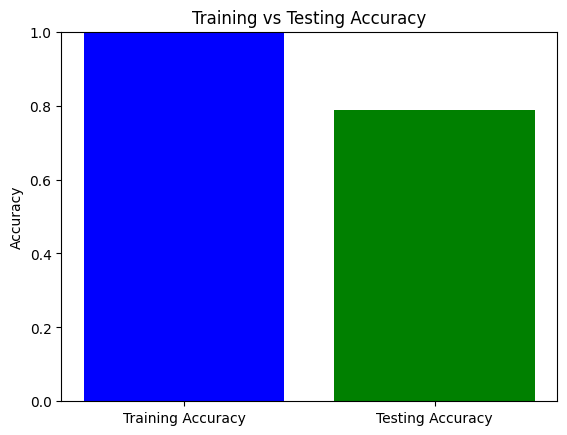

In [22]:
# Confusion Matrix for training set
train_cm = confusion_matrix(train_labels, train_predicted_labels)
disp_train = ConfusionMatrixDisplay(confusion_matrix=train_cm)
disp_train.plot()
plt.title("Confusion Matrix - Training Set")
plt.show()

# Confusion Matrix for test set
test_cm = confusion_matrix(test_labels, test_predicted_labels1)
disp_test = ConfusionMatrixDisplay(confusion_matrix=test_cm)
disp_test.plot()
plt.title("Confusion Matrix - Test Set")
plt.show()

# Classification report for test set
test_classification_report = classification_report(test_labels, test_predicted_labels1)
print("Classification Report - Test Set")
print(test_classification_report)

# Plot training and testing accuracies
accuracies = {
    "Training Accuracy": train_accuracy,
    "Testing Accuracy": test_accuracy
}

plt.bar(accuracies.keys(), accuracies.values(), color=['blue', 'green'])
plt.ylim(0, 1)
plt.ylabel('Accuracy')
plt.title('Training vs Testing Accuracy')
plt.show()

In [23]:
from sklearn import metrics
import numpy as np
from sklearn.metrics import f1_score
# Model Precision: what percentage of positive tuples are labeled as such?
print("Precision:",metrics.precision_score(test_labels, test_predicted_labels1))

# Model Recall: what percentage of positive tuples are labelled as such?
print("Recall:",metrics.recall_score(test_labels, test_predicted_labels1))
#F1_score
print('f1_score=',f1_score(test_labels, test_predicted_labels1, average='macro'))

Precision: 0.7888631090487239
Recall: 0.8018867924528302
f1_score= 0.7874593073784377


In [24]:
import numpy as np
from sklearn.metrics import det_curve
fpr, fnr, thresholds = det_curve(test_labels, test_predicted_labels1)
print(fpr)
print(fnr)

[1.         0.22721598]
[0.         0.19811321]


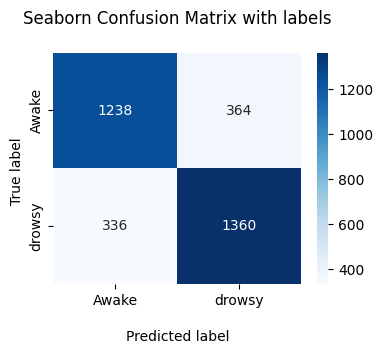

In [25]:
from sklearn.metrics import confusion_matrix
# importing library for plotting
import matplotlib.pyplot as plt
# plot the confusion matrix
f,ax = plt.subplots(figsize=(4,3))
#Generate the confusion matrix
cf_matrix = confusion_matrix(test_labels, test_predicted_labels1)
import seaborn as sns

ax = sns.heatmap(cf_matrix, annot=True, cmap=plt.cm.Blues, fmt='g')

ax.set_title('Seaborn Confusion Matrix with labels\n');
ax.set_xlabel('\nPredicted label')
ax.set_ylabel('True label ');

## Ticket labels - List must be in alphabetical order
ax.xaxis.set_ticklabels(['Awake','drowsy'])
ax.yaxis.set_ticklabels(['Awake','drowsy'])

## Display the visualization of the Confusion Matrix.
plt.show()

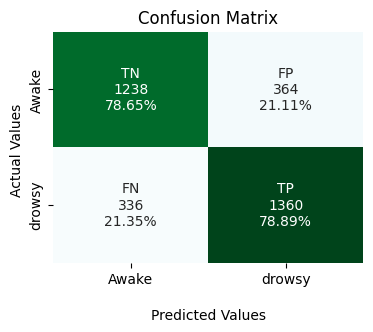

In [26]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Assuming you have y_test and predictions1 defined

# Generate the confusion matrix
cf_matrix = confusion_matrix(test_labels, test_predicted_labels1)

# Calculate column-wise percentages
cf_col_percentages = cf_matrix / np.sum(cf_matrix, axis=0) * 100

# Group names, counts, and percentages
group_counts = ["{0:0.0f}".format(value) for value in cf_matrix.flatten()]
group_names = ['TN', 'FP', 'FN', 'TP']
group_col_percentages = ["{0:.2f}%".format(value) for value in cf_col_percentages.flatten()]
labels = [f"{v1}\n{v2}\n{v3}" for v1, v2, v3 in zip(group_names,group_counts, group_col_percentages)]
labels = np.asarray(labels).reshape(2, 2)


# Plot the confusion matrix with annotations and use a clear green color
f, ax = plt.subplots(figsize=(4, 3))
sns.heatmap(cf_matrix, annot=labels, fmt='', cmap='BuGn', cbar=False)

# Set labels
ax.set_title('Confusion Matrix')
ax.set_xlabel('\nPredicted Values')



ax.set_ylabel('Actual Values ')

# Set tick labels
ax.xaxis.set_ticklabels(['Awake','drowsy'])
ax.yaxis.set_ticklabels(['Awake','drowsy'])

# Display the visualization of the Confusion Matrix
plt.show()


AUC for our classifier is: 0.7873354062139307


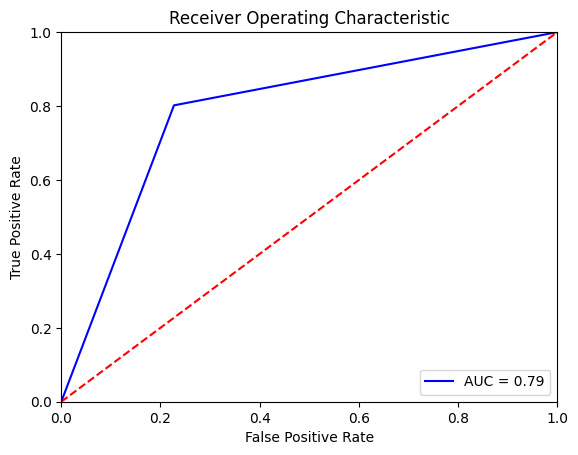

In [27]:
# Importing all necessary libraries
from sklearn.metrics import roc_curve, auc

fpr, tpr, threshold = roc_curve(test_labels, test_predicted_labels1)
roc_auc = auc(fpr, tpr)

# Printing AUC
print(f"AUC for our classifier is: {roc_auc}")

# Plotting the ROC
plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr, 'b', label = 'AUC = %0.2f' % roc_auc)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

# **RF**

In [28]:
from sklearn.ensemble import RandomForestClassifier

In [29]:

# Create a Random Forest classifier
classifier = RandomForestClassifier(n_estimators=100, random_state=42)
t7 = time.time()
# Train the classifier
classifier.fit(train_features, train_labels)
t8 = time.time()
temps_execution = t8 - t7
print(f"Training time for Random Forest: {temps_execution} seconds.")



Training time for Random Forest: 378.768027305603 seconds.


In [30]:
# Predict labels for the training set
train_predicted_labels = classifier.predict(train_features)
train_accuracy = metrics.accuracy_score(train_labels, train_predicted_labels)

t9 = time.time()
# Predict labels for the test set
test_predicted_labels2 = classifier.predict(test_features)
t10 = time.time()
test_accuracy = metrics.accuracy_score(test_labels, test_predicted_labels2)

temps_execution = t10 - t9
print(f"Testing time for Random Forest: {temps_execution} seconds.")

# Print accuracies
print("Training Accuracy:", train_accuracy)
print("Testing Accuracy:", test_accuracy)



Testing time for Random Forest: 0.563255786895752 seconds.
Training Accuracy: 1.0
Testing Accuracy: 0.9184354154032747


In [31]:
# Save the trained Random Forest model to a file
model_filename = 'random_forest_model.pkl'
joblib.dump(classifier, model_filename)
print("Model saved!")

Model saved!


In [32]:
from sklearn import metrics
import numpy as np
from sklearn.metrics import f1_score
# Model Precision: what percentage of positive tuples are labeled as such?
print("Precision:",metrics.precision_score(test_labels, test_predicted_labels2))

# Model Recall: what percentage of positive tuples are labelled as such?
print("Recall:",metrics.recall_score(test_labels, test_predicted_labels2))
#F1_score
print('f1_score=',f1_score(test_labels, test_predicted_labels2, average='macro'))

Precision: 0.914103308183401
Recall: 0.9286556603773585
f1_score= 0.9183254753219962


In [33]:
import numpy as np
from sklearn.metrics import det_curve
fpr, fnr, thresholds = det_curve(test_labels, test_predicted_labels2)
print(fpr)
print(fnr)

[1.         0.09238452]
[0.         0.07134434]


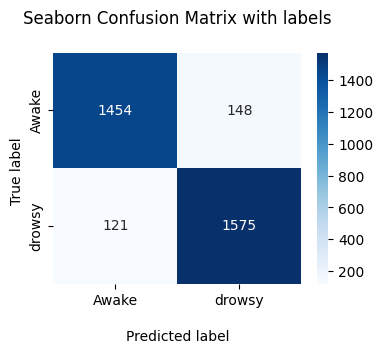

In [34]:
from sklearn.metrics import confusion_matrix
# importing library for plotting
import matplotlib.pyplot as plt
# plot the confusion matrix
f,ax = plt.subplots(figsize=(4,3))
#Generate the confusion matrix
cf_matrix = confusion_matrix(test_labels, test_predicted_labels2)
import seaborn as sns

ax = sns.heatmap(cf_matrix, annot=True, cmap=plt.cm.Blues, fmt='g')

ax.set_title('Seaborn Confusion Matrix with labels\n');
ax.set_xlabel('\nPredicted label')
ax.set_ylabel('True label ');

## Ticket labels - List must be in alphabetical order
ax.xaxis.set_ticklabels(['Awake','drowsy'])
ax.yaxis.set_ticklabels(['Awake','drowsy'])

## Display the visualization of the Confusion Matrix.
plt.show()

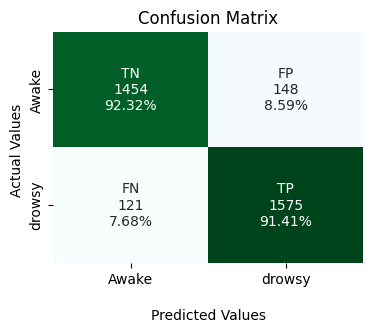

In [35]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Assuming you have y_test and predictions1 defined

# Generate the confusion matrix
cf_matrix = confusion_matrix(test_labels, test_predicted_labels2)

# Calculate column-wise percentages
cf_col_percentages = cf_matrix / np.sum(cf_matrix, axis=0) * 100

# Group names, counts, and percentages
group_counts = ["{0:0.0f}".format(value) for value in cf_matrix.flatten()]
group_names = ['TN', 'FP', 'FN', 'TP']
group_col_percentages = ["{0:.2f}%".format(value) for value in cf_col_percentages.flatten()]
labels = [f"{v1}\n{v2}\n{v3}" for v1, v2, v3 in zip(group_names,group_counts, group_col_percentages)]
labels = np.asarray(labels).reshape(2, 2)


# Plot the confusion matrix with annotations and use a clear green color
f, ax = plt.subplots(figsize=(4, 3))
sns.heatmap(cf_matrix, annot=labels, fmt='', cmap='BuGn', cbar=False)

# Set labels
ax.set_title('Confusion Matrix')
ax.set_xlabel('\nPredicted Values')
ax.set_ylabel('Actual Values ')

# Set tick labels
ax.xaxis.set_ticklabels(['Awake','drowsy'])
ax.yaxis.set_ticklabels(['Awake','drowsy'])

# Display the visualization of the Confusion Matrix
plt.show()

AUC for our classifier is: 0.9181355705132735


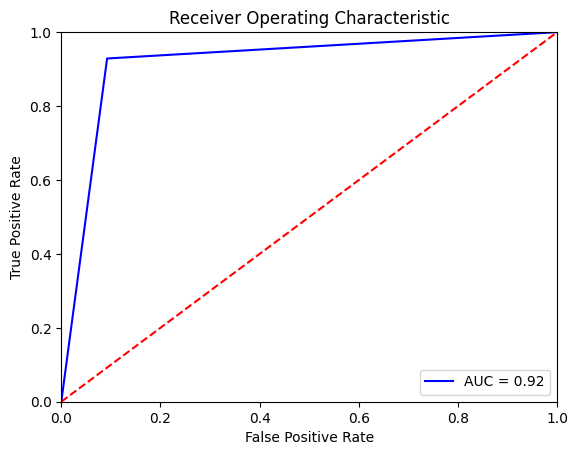

In [36]:
# Importing all necessary libraries
from sklearn.metrics import roc_curve, auc

fpr, tpr, threshold = roc_curve(test_labels, test_predicted_labels2)
roc_auc = auc(fpr, tpr)

# Printing AUC
print(f"AUC for our classifier is: {roc_auc}")

# Plotting the ROC
plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr, 'b', label = 'AUC = %0.2f' % roc_auc)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

AUC for our first classifier is: 0.7873354062139307
AUC for our second classifier is: 0.9181355705132735


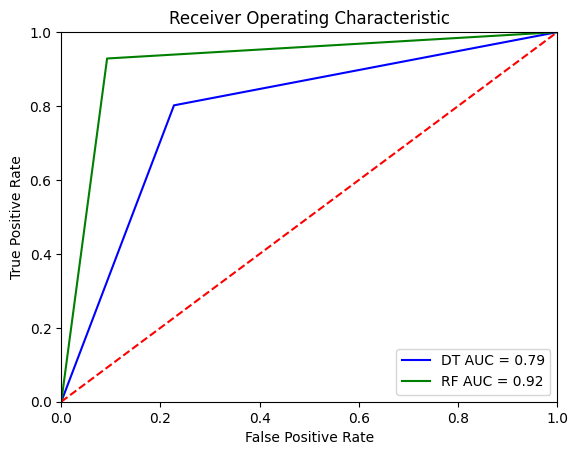

In [37]:
# Importing all necessary libraries
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Compute ROC curve and AUC for the first set of labels and predictions
fpr1, tpr1, threshold1 = roc_curve(test_labels, test_predicted_labels1)
roc_auc1 = auc(fpr1, tpr1)

# Compute ROC curve and AUC for the second set of labels and predictions
fpr2, tpr2, threshold2 = roc_curve(test_labels, test_predicted_labels2)
roc_auc2 = auc(fpr2, tpr2)

# Printing AUC
print(f"AUC for our first classifier is: {roc_auc1}")
print(f"AUC for our second classifier is: {roc_auc2}")

# Plotting the ROC curves on the same graph
plt.title('Receiver Operating Characteristic')
plt.plot(fpr1, tpr1, color='blue', label=f'DT AUC = {roc_auc1:.2f}')
plt.plot(fpr2, tpr2, color='green', label=f'RF AUC = {roc_auc2:.2f}')
plt.legend(loc='lower right')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()


AUC for our first classifier is: 0.7873354062139307
AUC for our second classifier is: 0.9181355705132735


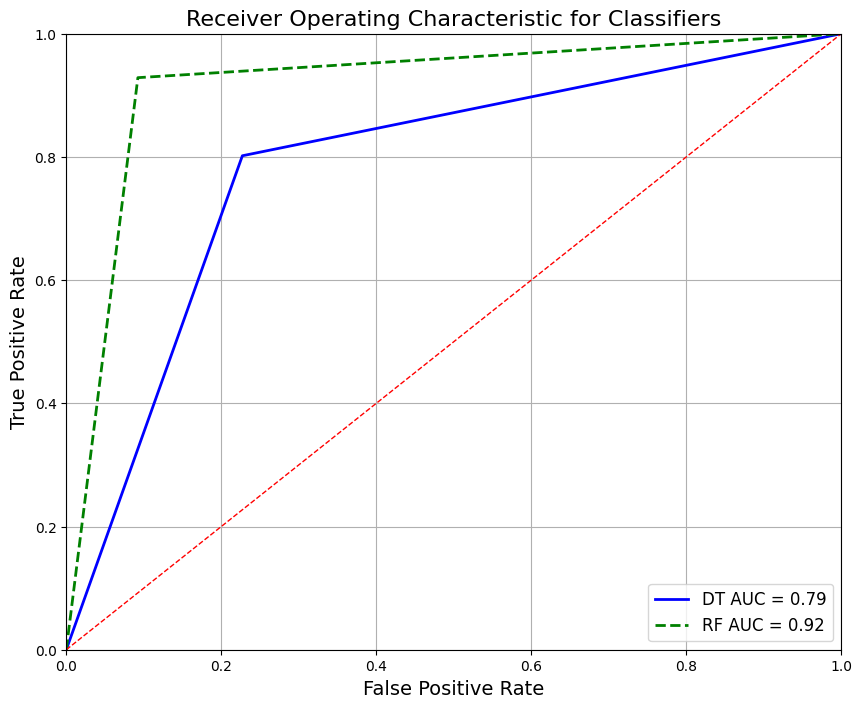

In [38]:
# Importing all necessary libraries
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Compute ROC curve and AUC for the first set of labels and predictions
fpr1, tpr1, threshold1 = roc_curve(test_labels, test_predicted_labels1)
roc_auc1 = auc(fpr1, tpr1)

# Compute ROC curve and AUC for the second set of labels and predictions
fpr2, tpr2, threshold2 = roc_curve(test_labels, test_predicted_labels2)
roc_auc2 = auc(fpr2, tpr2)

# Printing AUC
print(f"AUC for our first classifier is: {roc_auc1}")
print(f"AUC for our second classifier is: {roc_auc2}")

# Plotting the ROC curves on the same graph
plt.figure(figsize=(10, 8))
plt.title('Receiver Operating Characteristic for Classifiers', fontsize=16)
plt.plot(fpr1, tpr1, color='blue', linestyle='-', linewidth=2, label=f'DT AUC = {roc_auc1:.2f}')
plt.plot(fpr2, tpr2, color='green', linestyle='--', linewidth=2, label=f'RF AUC = {roc_auc2:.2f}')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', linewidth=1)
plt.legend(loc='lower right', fontsize=12)
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate', fontsize=14)
plt.xlabel('False Positive Rate', fontsize=14)
plt.grid(True)
plt.show()


AUC for our first classifier is: 0.7873354062139307
AUC for our second classifier is: 0.9181355705132735


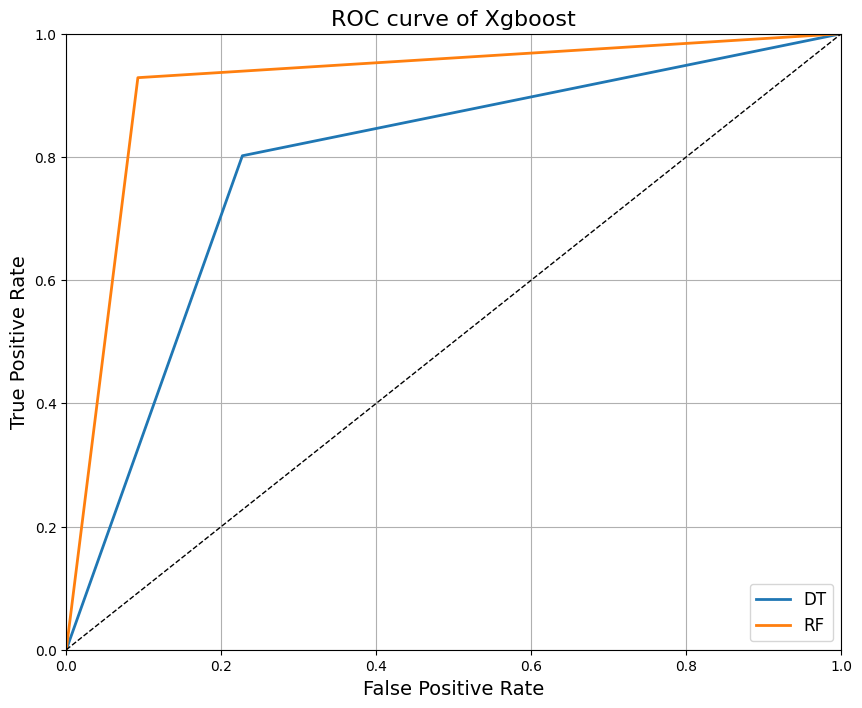

In [39]:
# Importing all necessary libraries
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Compute ROC curve and AUC for the first set of labels and predictions
fpr1, tpr1, threshold1 = roc_curve(test_labels, test_predicted_labels1)
roc_auc1 = auc(fpr1, tpr1)

# Compute ROC curve and AUC for the second set of labels and predictions
fpr2, tpr2, threshold2 = roc_curve(test_labels, test_predicted_labels2)
roc_auc2 = auc(fpr2, tpr2)

# Printing AUC
print(f"AUC for our first classifier is: {roc_auc1}")
print(f"AUC for our second classifier is: {roc_auc2}")
# Plotting the ROC curves on the same graph
plt.figure(figsize=(10, 8))
plt.title('ROC curve of Xgboost', fontsize=16)
plt.plot(fpr1, tpr1, linestyle='-', linewidth=2, label='DT')
plt.plot(fpr2, tpr2, linestyle='-', linewidth=2, label='RF')

plt.plot([0, 1], [0, 1], color='black', linestyle='--', linewidth=1)
plt.legend(loc='lower right', fontsize=12)
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate', fontsize=14)
plt.xlabel('False Positive Rate', fontsize=14)
plt.grid(True)

AUC for our first classifier is: 0.9649722928886063
AUC for our second classifier is: 0.9408338338868867
AUC for our third classifier is: 0.7873354062139307
AUC for our fourth classifier is: 0.9181355705132735


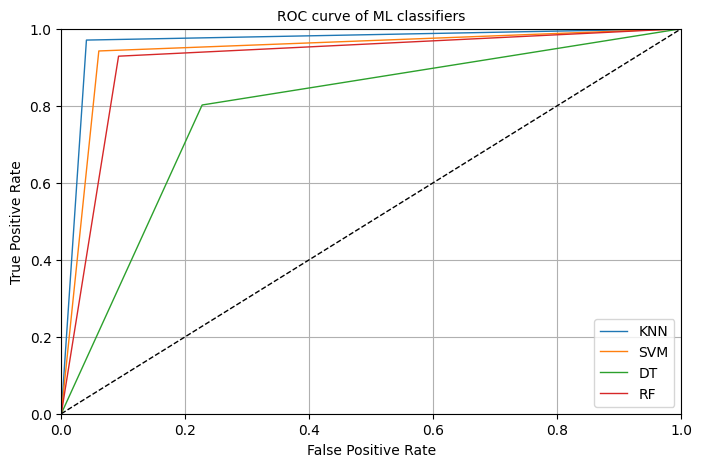

In [49]:
# Importing all necessary libraries
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
# Compute ROC curve and AUC for the second set of labels and predictions
fpr3, tpr3, threshold3 = roc_curve(test_labels, test_predicted_labels3)
roc_auc3 = auc(fpr3, tpr3)
# Compute ROC curve and AUC for the second set of labels and predictions
fpr4, tpr4, threshold4 = roc_curve(test_labels, test_predicted_labels4)
roc_auc4 = auc(fpr4, tpr4)
# Compute ROC curve and AUC for the first set of labels and predictions
fpr1, tpr1, threshold1 = roc_curve(test_labels, test_predicted_labels1)
roc_auc1 = auc(fpr1, tpr1)

# Compute ROC curve and AUC for the second set of labels and predictions
fpr2, tpr2, threshold2 = roc_curve(test_labels, test_predicted_labels2)
roc_auc2 = auc(fpr2, tpr2)


# Printing AUC
print(f"AUC for our first classifier is: {roc_auc3}")
print(f"AUC for our second classifier is: {roc_auc4}")
print(f"AUC for our third classifier is: {roc_auc1}")
print(f"AUC for our fourth classifier is: {roc_auc2}")
# Plotting the ROC curves on the same graph
plt.figure(figsize=(8, 5))
plt.title('ROC curve of ML classifiers', fontsize=10)
plt.plot(fpr3, tpr3, linestyle='-', linewidth=1, label='KNN')
plt.plot(fpr4, tpr4, linestyle='-', linewidth=1, label='SVM')
plt.plot(fpr1, tpr1, linestyle='-', linewidth=1, label='DT')
plt.plot(fpr2, tpr2, linestyle='-', linewidth=1, label='RF')

plt.plot([0, 1], [0, 1], color='black', linestyle='--', linewidth=1)
plt.legend(loc='lower right', fontsize=10)
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate', fontsize=10)
plt.xlabel('False Positive Rate', fontsize=10)
plt.grid(True)